In [1]:
import numpy as np
import xarray as xr
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import cartopy.crs as ccrs
import cartopy.feature as cfeature
cmap = plt.cm.get_cmap('RdYlBu_r')

/var/folders/7w/k64x4hxx1x96s_hxn35hcg0w0000gp/T/ipykernel_59950/1623294169.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlBu_r')


In [2]:
x = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_US_2019/NO2_US_pkg/input_variables/tSATLON_US_MAP.npy')
y = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_US_2019/NO2_US_pkg/input_variables/tSATLAT_US_MAP.npy')

In [3]:
Dir = '/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_US_2019/NO2_US_pkg/input_variables/NDVI_input/2019/'
ds = np.load(Dir + 'NDVI-MOD13A3_001x001_US_201901.npy')
print(ds.shape)

(6000, 10000)


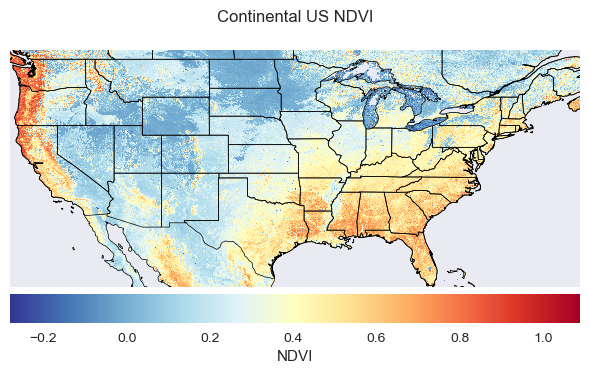

In [4]:
fig, ax = plt.subplots(figsize=(6, 4), 
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.set_extent([-125, -65, 25, 50], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(x, y, ds, 
                     transform=ccrs.PlateCarree(),
                     cmap=cmap,
                     vmin=np.nanmin(ds),
                     vmax=np.nanmax(ds))

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('NDVI')

plt.title('Continental US NDVI', pad=20)

plt.tight_layout()
plt.show()